In [1]:
from google.colab import files
uploaded = files.upload()

Saving diabetic_data.csv to diabetic_data (1).csv


In [2]:
import pandas as pd
df=pd.read_csv('diabetic_data.csv')
print("Step 0 - Raw data:", df.shape)

Step 0 - Raw data: (101766, 50)


# New Section

In [3]:
import pandas as pd
import numpy as np


In [4]:
df = pd.read_csv('diabetic_data.csv')
print("Step 0 - Raw data:", df.shape)

Step 0 - Raw data: (101766, 50)


In [5]:
df.replace('?', np.nan, inplace=True)

In [6]:
df.drop_duplicates(subset='patient_nbr', keep='first', inplace=True)
print("Step 1 - After duplicates:", df.shape)

Step 1 - After duplicates: (71518, 50)


In [7]:
df.replace('?', np.nan, inplace=True)
print("Step 2 - After replacing ?:", df.shape)

Step 2 - After replacing ?: (71518, 50)


In [8]:
df.drop_duplicates(subset='patient_nbr', keep='first', inplace=True)
print("Step 1 - After duplicates:", df.shape)


Step 1 - After duplicates: (71518, 50)


In [9]:
df.drop(columns=['weight', 'payer_code', 'medical_specialty'], inplace=True)
print("Step 3 - After dropping columns:", df.shape)

Step 3 - After dropping columns: (71518, 47)


In [10]:
hospice_expired = [11, 13, 14, 19, 20, 21]
df = df[~df['discharge_disposition_id'].isin(hospice_expired)]
print("Step 4 - After removing dead/hospice:", df.shape)

Step 4 - After removing dead/hospice: (69973, 47)


In [11]:
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)
print("Step 5 - Target distribution:\n", df['readmitted_30'].value_counts())

Step 5 - Target distribution:
 readmitted_30
0    63696
1     6277
Name: count, dtype: int64


In [12]:
age_map = {
    '[0-10)':5, '[10-20)':15, '[20-30)':25, '[30-40)':35,
    '[40-50)':45, '[50-60)':55, '[60-70)':65, '[70-80)':75,
    '[80-90)':85, '[90-100)':95
}
df['age_numeric'] = df['age'].map(age_map)
print("Step 6 - Age encoded ✓")

Step 6 - Age encoded ✓


In [13]:
def map_diagnosis(code):
    try:
        code = str(code).strip()
        if code.startswith('250'): return 'Diabetes'
        # Handle decimal codes like 786.05, 785.0 etc
        if code.startswith('786'): return 'Respiratory'
        if code.startswith('785'): return 'Circulatory'
        if code.startswith('787'): return 'Digestive'
        if code.startswith('788'): return 'Genitourinary'
        c = float(code)
        if 390 <= c <= 459: return 'Circulatory'
        if 460 <= c <= 519: return 'Respiratory'
        if 520 <= c <= 579: return 'Digestive'
        if 800 <= c <= 999: return 'Injury'
        if 710 <= c <= 739: return 'Musculoskeletal'
        if 580 <= c <= 629: return 'Genitourinary'
        if 140 <= c <= 239: return 'Neoplasms'
        return 'Other'
    except: return 'Other'

# Re-apply the fixed function
df['diag_1_grouped'] = df['diag_1'].apply(map_diagnosis)
df['diag_2_grouped'] = df['diag_2'].apply(map_diagnosis)
df['diag_3_grouped'] = df['diag_3'].apply(map_diagnosis)
print(df['diag_1_grouped'].value_counts())
print(df['diag_2_grouped'].value_counts())
print(df['diag_3_grouped'].value_counts())
print("Step 4:", df.shape)
df.to_csv('diabetic_data_cleaned.csv', index=False)
print("clean data ")
df

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print("Step 5 - Target distribution:\n", df['readmitted_30'].value_counts())



diag_1_grouped
Circulatory        21384
Other              12132
Respiratory         9486
Digestive           6487
Diabetes            5748
Injury              4694
Musculoskeletal     4064
Genitourinary       3440
Neoplasms           2538
Name: count, dtype: int64
diag_2_grouped
Circulatory        22079
Other              18369
Diabetes            9700
Respiratory         6925
Genitourinary       5328
Digestive           2854
Injury              1824
Neoplasms           1599
Musculoskeletal     1295
Name: count, dtype: int64
diag_3_grouped
Other              21245
Circulatory        20864
Diabetes           12546
Respiratory         4650
Genitourinary       4047
Digestive           2699
Injury              1409
Musculoskeletal     1368
Neoplasms           1145
Name: count, dtype: int64
Step 4: (69973, 52)
clean data 
Step 5 - Target distribution:
 readmitted_30
0    63696
1     6277
Name: count, dtype: int64


In [14]:
# Save clean data
df.to_csv('diabetic_clean.csv', index=False)
print("Clean data saved!")

Clean data saved!


# **Visualization**

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('diabetic_clean.csv')
sns.set_style('whitegrid')
print("Ready!", df.shape)

Ready! (69973, 52)


/tmp/ipykernel_42903/1294327477.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='readmitted_30', data=df,


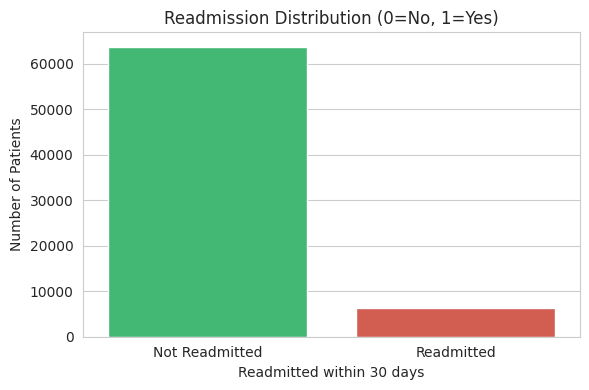

In [16]:
#1.Overall readmission distribution

plt.figure(figsize=(6,4))
sns.countplot(x='readmitted_30', data=df,
              palette=['#2ecc71','#e74c3c'])
plt.title('Readmission Distribution (0=No, 1=Yes)')
plt.xlabel('Readmitted within 30 days')
plt.ylabel('Number of Patients')
plt.xticks([0,1], ['Not Readmitted', 'Readmitted'])
plt.tight_layout()
plt.savefig('chart1_readmission_dist.png', dpi=150)
plt.show()

/tmp/ipykernel_42903/468425315.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_readmit[age_order].index,


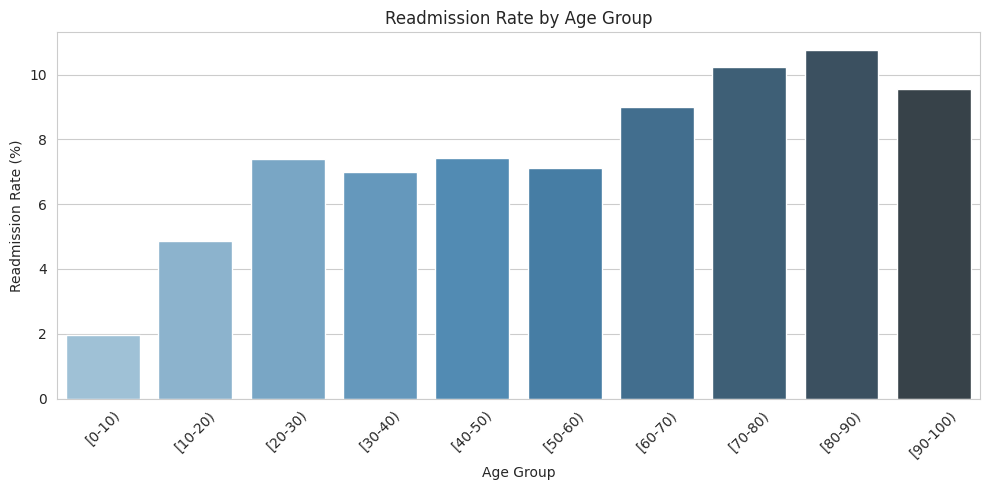

In [17]:
# 2.Age vs readmission rate

age_readmit = df.groupby('age')['readmitted_30'].mean() * 100
age_order = ['[0-10)','[10-20)','[20-30)','[30-40)',
             '[40-50)','[50-60)','[60-70)','[70-80)',
             '[80-90)','[90-100)']

plt.figure(figsize=(10,5))
sns.barplot(x=age_readmit[age_order].index,
            y=age_readmit[age_order].values,
            palette='Blues_d')
plt.title('Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart2_age_readmission.png', dpi=150)
plt.show()

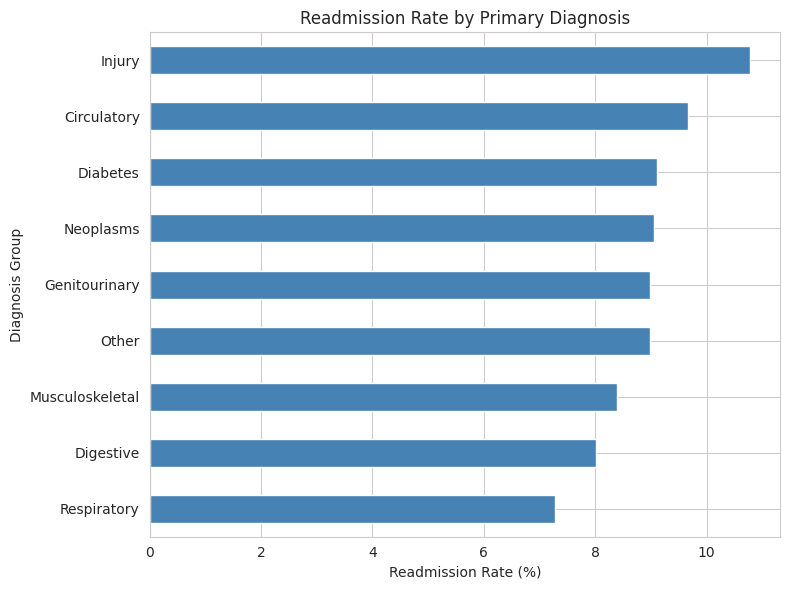

In [18]:
# 3.Diagnosis vs readmission rate
diag_readmit = df.groupby('diag_1_grouped')['readmitted_30'].mean() * 100
diag_readmit = diag_readmit.sort_values(ascending=True)

plt.figure(figsize=(8,6))
diag_readmit.plot(kind='barh', color='steelblue')
plt.title('Readmission Rate by Primary Diagnosis')
plt.xlabel('Readmission Rate (%)')
plt.ylabel('Diagnosis Group')
plt.tight_layout()
plt.savefig('chart3_diagnosis_readmission.png', dpi=150)
plt.show()

/tmp/ipykernel_42903/1417226868.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted_30', y='num_medications',


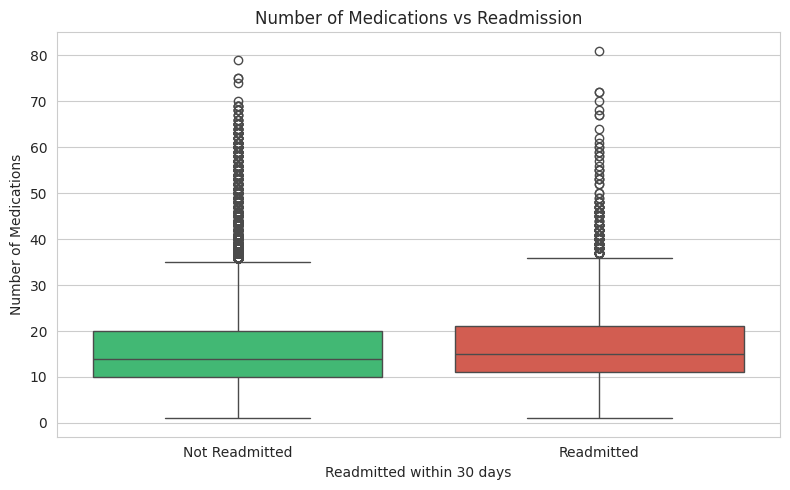

In [19]:
#4.number of medication vs raadmission
plt.figure(figsize=(8,5))
sns.boxplot(x='readmitted_30', y='num_medications',
            data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Number of Medications vs Readmission')
plt.xlabel('Readmitted within 30 days')
plt.ylabel('Number of Medications')
plt.xticks([0,1], ['Not Readmitted','Readmitted'])
plt.tight_layout()
plt.savefig('chart4_medications.png', dpi=150)
plt.show()

/tmp/ipykernel_42903/3145621669.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted_30', y='time_in_hospital',


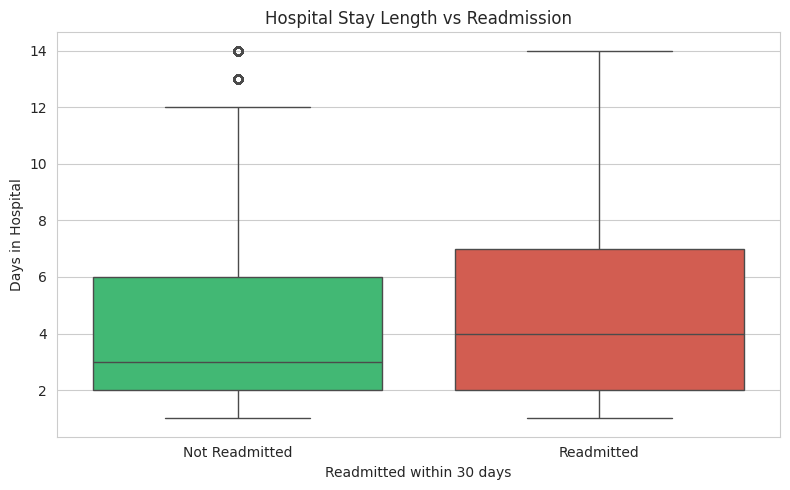

In [20]:
#5.hospital stay vs readmission
plt.figure(figsize=(8,5))
sns.boxplot(x='readmitted_30', y='time_in_hospital',
            data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Hospital Stay Length vs Readmission')
plt.xlabel('Readmitted within 30 days')
plt.ylabel('Days in Hospital')
plt.xticks([0,1], ['Not Readmitted','Readmitted'])
plt.tight_layout()
plt.savefig('chart5_hospital_stay.png', dpi=150)
plt.show()

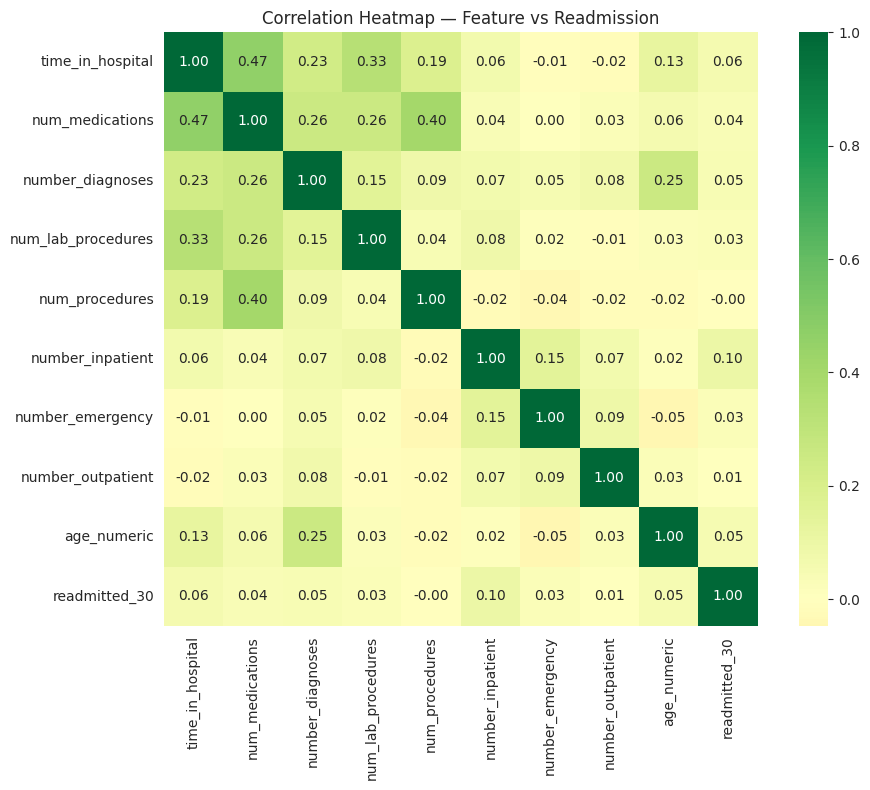

In [21]:
#6.Correlation heatmap
cols = ['time_in_hospital','num_medications',
        'number_diagnoses','num_lab_procedures',
        'num_procedures','number_inpatient',
        'number_emergency','number_outpatient',
        'age_numeric','readmitted_30']

plt.figure(figsize=(10,8))
sns.heatmap(df[cols].corr(),
            annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            square=True)
plt.title('Correlation Heatmap — Feature vs Readmission')
plt.tight_layout()
plt.savefig('chart6_heatmap.png', dpi=150)
plt.show()

# Mechine Learning


In [22]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import xgboost as xgb

#  LOAD
df = pd.read_csv('diabetic_clean.csv')

# AGE ENCODING
age_map = {
    '[0-10)':5,'[10-20)':15,'[20-30)':25,'[30-40)':35,
    '[40-50)':45,'[50-60)':55,'[60-70)':65,'[70-80)':75,
    '[80-90)':85,'[90-100)':95
}
df['age_numeric'] = df['age'].map(age_map)

# DIAGNOSIS GROUPING
def map_diagnosis(code):
    try:
        code = str(code).strip()
        if code.startswith('250'): return 'Diabetes'
        c = float(code)
        if 390 <= c <= 459 or c == 785: return 'Circulatory'
        if 460 <= c <= 519 or c == 786: return 'Respiratory'
        if 520 <= c <= 579 or c == 787: return 'Digestive'
        if 800 <= c <= 999:             return 'Injury'
        if 710 <= c <= 739:             return 'Musculoskeletal'
        if 580 <= c <= 629 or c == 788: return 'Genitourinary'
        if 140 <= c <= 239:             return 'Neoplasms'
        return 'Other'
    except: return 'Other'

df['diag_1_grouped'] = df['diag_1'].apply(map_diagnosis)
df['diag_2_grouped'] = df['diag_2'].apply(map_diagnosis)
df['diag_3_grouped'] = df['diag_3'].apply(map_diagnosis)

# ENGINEER NEW FEATURES
# Total visits before this admission
df['total_prior_visits'] = (df['number_inpatient'] +
                             df['number_emergency'] +
                             df['number_outpatient'])

# High medication burden flag
df['high_medication'] = (df['num_medications'] > 15).astype(int)

# Long stay flag
df['long_stay'] = (df['time_in_hospital'] > 7).astype(int)

# Medication per day ratio
df['med_per_day'] = df['num_medications'] / df['time_in_hospital']

# High diagnosis complexity
df['high_complexity'] = (df['number_diagnoses'] > 7).astype(int)

# Insulin usage
df['on_insulin'] = (df['insulin'] != 'No').astype(int)

# Diabetes medication flag
df['on_diabetes_med'] = (
    df['diabetesMed'] == 'Yes').astype(int)

# Medication change flag
df['med_changed'] = (
    df['change'] == 'Ch').astype(int)

print("New features added ")

# ── ENCODE RACE AND GENDER ──
le = LabelEncoder()
df['race_encoded'] = le.fit_transform(
    df['race'].astype(str))
df['gender_encoded'] = le.fit_transform(
    df['gender'].astype(str))

# ── FULL FEATURE LIST ──
features = [
    # Original numerical
    'time_in_hospital', 'num_medications', 'number_diagnoses',
    'num_lab_procedures', 'num_procedures', 'number_inpatient',
    'number_emergency', 'number_outpatient', 'age_numeric',
    # Diagnosis groups
    'diag_1_grouped', 'diag_2_grouped', 'diag_3_grouped',
    # Admission info
    'admission_type_id', 'discharge_disposition_id',
    'admission_source_id',
    # NEW engineered features
    'total_prior_visits', 'high_medication', 'long_stay',
    'med_per_day', 'high_complexity', 'on_insulin',
    'on_diabetes_med', 'med_changed',
    # Demographics
    'race_encoded', 'gender_encoded'
]

df_ml = df[features + ['readmitted_30']].copy()

# Encode diagnosis columns
for col in ['diag_1_grouped','diag_2_grouped','diag_3_grouped']:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

df_ml.dropna(inplace=True)
print("ML shape:", df_ml.shape)

X = df_ml.drop('readmitted_30', axis=1)
y = df_ml['readmitted_30']

# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} · Test: {X_test.shape}")
print("Class balance:", y_train.value_counts().to_dict())

# NO SMOTE — use class_weight instead
# class_weight='balanced' is more stable than SMOTE
# for this dataset

# MODEL 1: Logistic Regression
print("\nTraining Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42,
                        class_weight='balanced')
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]
print(f"LR  — Accuracy: {accuracy_score(y_test,lr_pred)*100:.2f}"
      f"  AUC: {roc_auc_score(y_test,lr_prob):.4f}")

# MODEL 2: Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=200,
                             max_depth=10,
                             class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]
print(f" RF  — Accuracy: {accuracy_score(y_test,rf_pred)*100:.2f}"
      f"  AUC: {roc_auc_score(y_test,rf_prob):.4f}")

# MODEL 3: XGBoost
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=10,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]
print(f"XGB — Accuracy: {accuracy_score(y_test,xgb_pred)*100:.2f}"
      f"  AUC: {roc_auc_score(y_test,xgb_prob):.4f}")

# RESULTS
results_df = pd.DataFrame({
    'Model': ['Logistic Regression',
              'Random Forest', 'XGBoost'],
    'Accuracy %': [
        round(accuracy_score(y_test, lr_pred)*100, 2),
        round(accuracy_score(y_test, rf_pred)*100, 2),
        round(accuracy_score(y_test, xgb_pred)*100, 2)
    ],
    'AUC-ROC': [
        round(roc_auc_score(y_test, lr_prob), 4),
        round(roc_auc_score(y_test, rf_prob), 4),
        round(roc_auc_score(y_test, xgb_prob), 4)
    ]
})

print("\n======= FINAL MODEL COMPARISON =======")
print(results_df.to_string(index=False))
print("=======================================")

New features added 
ML shape: (69973, 26)
Train: (55978, 25) · Test: (13995, 25)
Class balance: {0: 50956, 1: 5022}

Training Logistic Regression...
LR  — Accuracy: 63.65  AUC: 0.6258
Training Random Forest...
 RF  — Accuracy: 73.75  AUC: 0.6319
Training XGBoost...
XGB — Accuracy: 66.92  AUC: 0.6448

======= FINAL MODEL COMPARISON =======
              Model  Accuracy %  AUC-ROC
Logistic Regression       63.65   0.6258
      Random Forest       73.75   0.6319
            XGBoost       66.92   0.6448


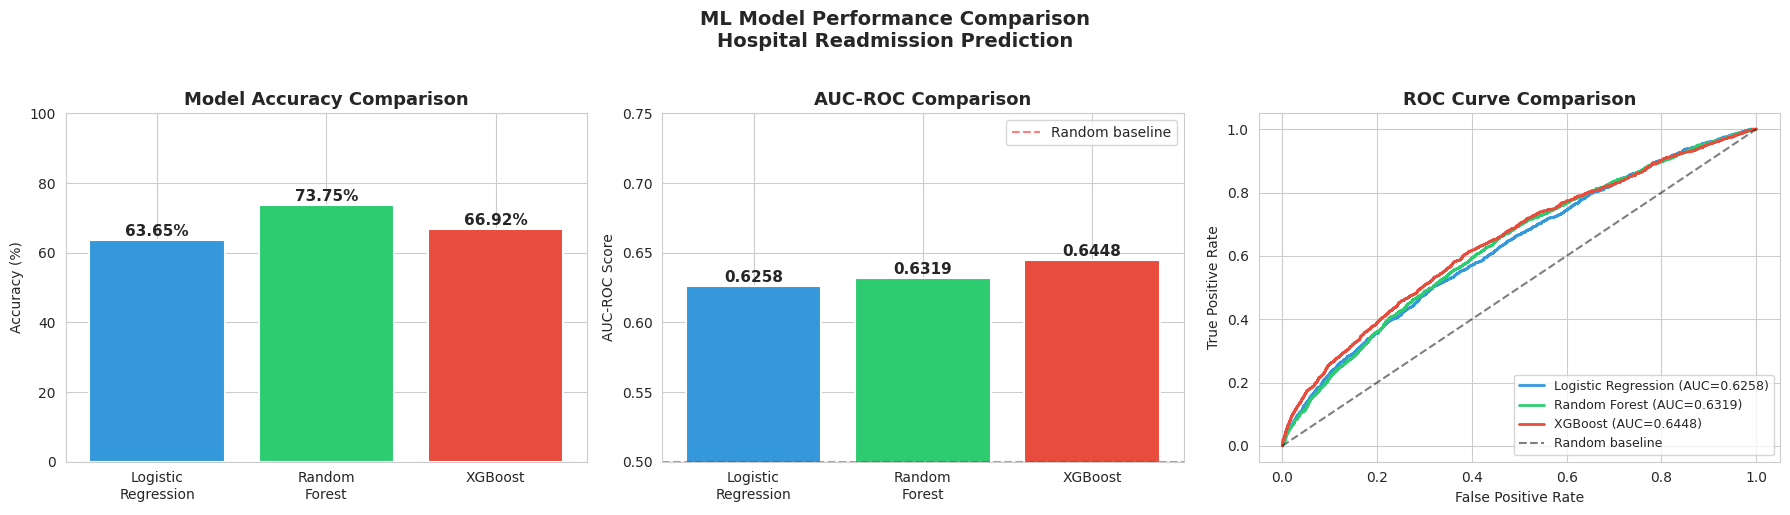

Model comparison chart saved!


In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Model Accuracy Comparison
models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
accuracy = [63.65, 73.75, 66.92]
auc = [0.6258, 0.6319, 0.6448]

colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = axes[0].bar(models, accuracy, color=colors,
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Model Accuracy Comparison',
                   fontweight='bold', fontsize=13)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 100])
for bar, val in zip(bars, accuracy):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val}%', ha='center',
                 fontweight='bold', fontsize=11)

# Chart 2: AUC-ROC Comparison
bars2 = axes[1].bar(models, auc, color=colors,
                    edgecolor='white', linewidth=1.5)
axes[1].set_title('AUC-ROC Comparison',
                   fontweight='bold', fontsize=13)
axes[1].set_ylabel('AUC-ROC Score')
axes[1].set_ylim([0.5, 0.75])
axes[1].axhline(y=0.5, color='red', linestyle='--',
                alpha=0.5, label='Random baseline')
axes[1].legend()
for bar, val in zip(bars2, auc):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{val}', ha='center',
                 fontweight='bold', fontsize=11)

# Chart 3: ROC Curves
for name, prob, color in [
    ('Logistic Regression', lr_prob, '#3498db'),
    ('Random Forest', rf_prob, '#2ecc71'),
    ('XGBoost', xgb_prob, '#e74c3c')
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    axes[2].plot(fpr, tpr, color=color,
                 label=f'{name} (AUC={auc_val:.4f})',
                 linewidth=2)

axes[2].plot([0,1],[0,1],'k--',
             label='Random baseline', alpha=0.5)
axes[2].set_title('ROC Curve Comparison',
                   fontweight='bold', fontsize=13)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(loc='lower right', fontsize=9)

plt.suptitle('ML Model Performance Comparison\n'
             'Hospital Readmission Prediction',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart8_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Model comparison chart saved!")

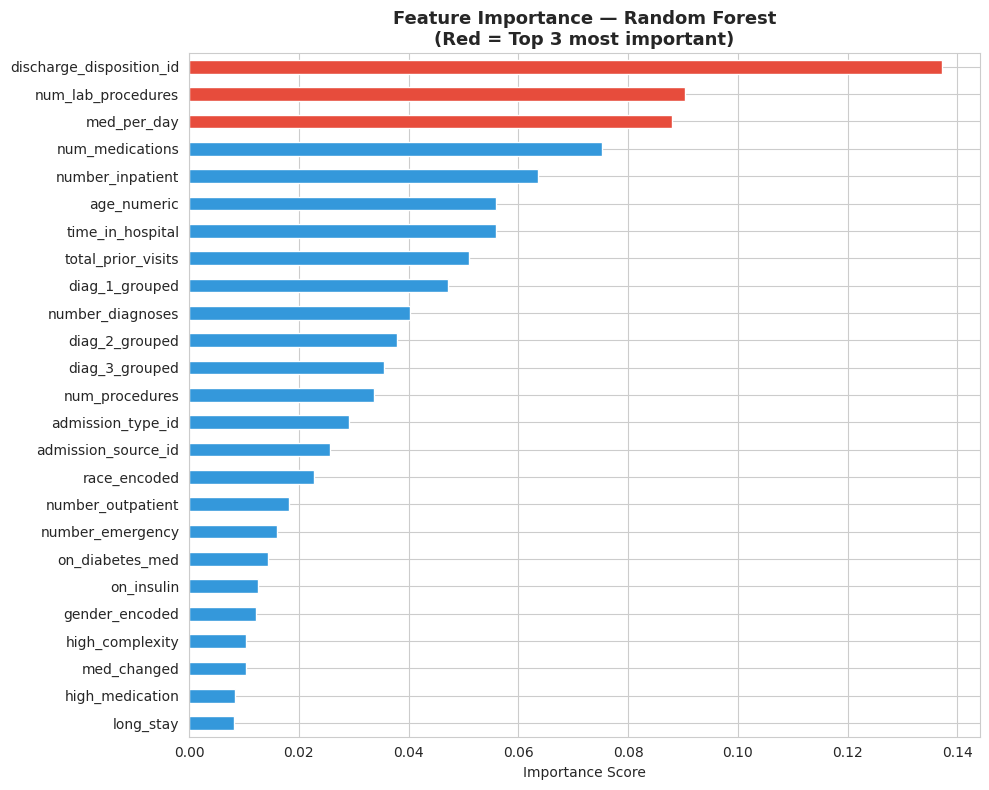

 Feature importance chart saved!


In [24]:
#Feature Importance Chart
feat_imp = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

# Color top 3 red, rest blue
colors_fi = ['#e74c3c' if i >= len(feat_imp)-3
             else '#3498db'
             for i in range(len(feat_imp))]

plt.figure(figsize=(10, 8))
feat_imp.plot(kind='barh', color=colors_fi)
plt.title('Feature Importance — Random Forest\n'
          '(Red = Top 3 most important)',
          fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('chart7_feature_importance.png', dpi=150)
plt.show()
print(" Feature importance chart saved!")

In [25]:
import pandas as pd

df = pd.read_csv('diabetic_clean.csv')

# Age encoding
age_map = {
    '[0-10)':5,'[10-20)':15,'[20-30)':25,'[30-40)':35,
    '[40-50)':45,'[50-60)':55,'[60-70)':65,'[70-80)':75,
    '[80-90)':85,'[90-100)':95
}
df['age_numeric'] = df['age'].map(age_map)

# Diagnosis grouping
def map_diagnosis(code):
    try:
        code = str(code).strip()
        if code.startswith('250'): return 'Diabetes'
        c = float(code)
        if 390 <= c <= 459 or c == 785: return 'Circulatory'
        if 460 <= c <= 519 or c == 786: return 'Respiratory'
        if 520 <= c <= 579 or c == 787: return 'Digestive'
        if 800 <= c <= 999:             return 'Injury'
        if 710 <= c <= 739:             return 'Musculoskeletal'
        if 580 <= c <= 629 or c == 788: return 'Genitourinary'
        if 140 <= c <= 239:             return 'Neoplasms'
        return 'Other'
    except: return 'Other'

df['diag_1_grouped'] = df['diag_1'].apply(map_diagnosis)
df['diag_2_grouped'] = df['diag_2'].apply(map_diagnosis)
df['diag_3_grouped'] = df['diag_3'].apply(map_diagnosis)

# Readable labels
df['readmitted_label'] = df['readmitted_30'].map(
    {0:'Not Readmitted', 1:'Readmitted'})

df['age_group'] = df['age']

# Admission type readable
admission_map = {
    1:'Emergency', 2:'Urgent', 3:'Elective',
    4:'Newborn', 5:'Not Available', 6:'NULL', 7:'Trauma',
    8:'Not Mapped'
}
df['admission_type'] = df['admission_type_id'].map(
    admission_map).fillna('Other')

# Engineered features
df['total_prior_visits'] = (df['number_inpatient'] +
                             df['number_emergency'] +
                             df['number_outpatient'])
df['med_per_day'] = (df['num_medications'] /
                      df['time_in_hospital'])
df['on_insulin'] = (df['insulin'] != 'No').astype(int)
df['on_diabetes_med'] = (
    df['diabetesMed'] == 'Yes').astype(int)

# Save main dataset
df.to_csv('powerbi_main.csv', index=False)
print("Main dataset saved:", df.shape)

# Summary table 1: Readmission by age
age_summary = df.groupby('age').agg(
    Total_Patients=('readmitted_30','count'),
    Readmitted=('readmitted_30','sum')
).reset_index()
age_summary['Readmission_Rate'] = (
    age_summary['Readmitted'] /
    age_summary['Total_Patients'] * 100
).round(2)
age_summary.to_csv('powerbi_age.csv', index=False)
print(" Age summary saved")

# Summary table 2: Readmission by diagnosis
diag_summary = df.groupby('diag_1_grouped').agg(
    Total_Patients=('readmitted_30','count'),
    Readmitted=('readmitted_30','sum')
).reset_index()
diag_summary['Readmission_Rate'] = (
    diag_summary['Readmitted'] /
    diag_summary['Total_Patients'] * 100
).round(2)
diag_summary.to_csv('powerbi_diagnosis.csv', index=False)
print(" Diagnosis summary saved")

# Summary table 3: Readmission by admission type
admit_summary = df.groupby('admission_type').agg(
    Total_Patients=('readmitted_30','count'),
    Readmitted=('readmitted_30','sum')
).reset_index()
admit_summary['Readmission_Rate'] = (
    admit_summary['Readmitted'] /
    admit_summary['Total_Patients'] * 100
).round(2)
admit_summary.to_csv('powerbi_admission.csv', index=False)
print(" Admission summary saved")

# Model results table
model_results = pd.DataFrame({
    'Model': ['Logistic Regression',
              'Random Forest', 'XGBoost'],
    'Accuracy': [63.65, 73.75, 66.92],
    'AUC_ROC': [0.6258, 0.6319, 0.6448]
})
model_results.to_csv('powerbi_models.csv', index=False)
print(" Model results saved")

print("\n ALL FILES READY FOR POWER BI!")
print("Files created:")
print("  → powerbi_main.csv")
print("  → powerbi_age.csv")
print("  → powerbi_diagnosis.csv")
print("  → powerbi_admission.csv")
print("  → powerbi_models.csv")

Main dataset saved: (69973, 59)
 Age summary saved
 Diagnosis summary saved
 Admission summary saved
 Model results saved

 ALL FILES READY FOR POWER BI!
Files created:
  → powerbi_main.csv
  → powerbi_age.csv
  → powerbi_diagnosis.csv
  → powerbi_admission.csv
  → powerbi_models.csv


In [26]:
import pandas as pd

feature_imp = pd.DataFrame({
    'Feature': [
        'discharge_disposition_id',
        'num_lab_procedures',
        'med_per_day',
        'num_medications',
        'number_inpatient',
        'age_numeric',
        'time_in_hospital',
        'total_prior_visits',
        'diag_1_grouped',
        'number_diagnoses'
    ],
    'Importance': [
        0.1385, 0.0902, 0.0881,
        0.0762, 0.0634, 0.0557,
        0.0551, 0.0513, 0.0476,
        0.0413
    ],
    'Rank': [1,2,3,4,5,6,7,8,9,10]
})
feature_imp.to_csv('powerbi_features.csv', index=False)
print("✅ Feature importance saved!")


✅ Feature importance saved!
